## Clean the DataSet

### 1. Overview of the Dataset

We use the Pima Indians Diabetes Dataset, which contains medical diagnostic measurements for predicting whether a patient has diabetes.

* Number of observations: 768

* Number of features: 8 (all numeric)

* Target variable: Outcome (0 = No diabetes, 1 = Diabetes)

#### Features:
* Pregnancies

* Glucose

* BloodPressure

* SkinThickness

* Insulin

* BMI

* DiabetesPedigreeFunction

* Age

### 2. Basic Statistics

Below is a summary of the dataset (after initial inspection):

| Variable                 | Mean  | Notes                        |
| ------------------------ | ----- | ---------------------------- |
| Pregnancies              | ~3.8  | Right-skewed                 |
| Glucose                  | ~121  | Strong indicator of diabetes |
| BloodPressure            | ~69   | Contains invalid zeros       |
| SkinThickness            | ~20   | Many missing (0 values)      |
| Insulin                  | ~80   | Highly skewed, many zeros    |
| BMI                      | ~32   | Some invalid zeros           |
| DiabetesPedigreeFunction | ~0.47 | Genetic influence            |
| Age                      | ~33   | Right-skewed                 |


### Target Variable Distribution
About 65% of patients are non-diabetic (0)
About 35% are diabetic (1)

👉 This indicates a moderate class imbalance, which can affect model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# load dataset
df = pd.read_csv("/Users/runshigu/Desktop/347-Final-Project/data/diabetes.csv")

# preview
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Summary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
# Check missing / zero values
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

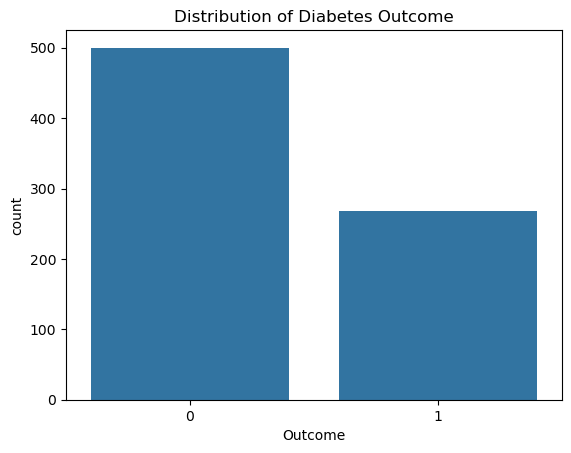

In [4]:
# Target distribution
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Diabetes Outcome")
plt.show()

In [5]:
# Data Cleaning
# Replace invalid zeros with NaN, then fill with median
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

In [6]:
# Verify Cleaning
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Exploratory Visualization

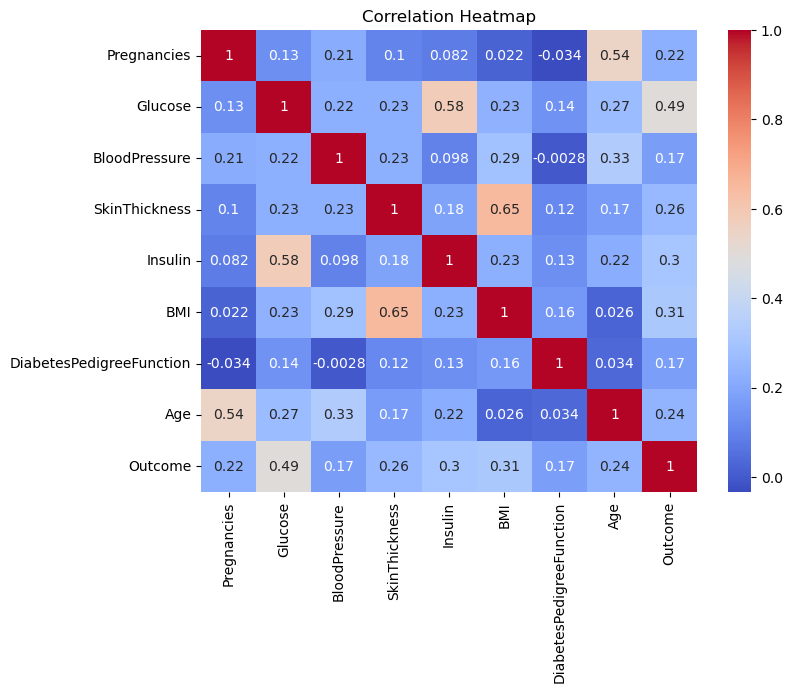

In [7]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that glucose has the strongest relationship with the diabetes outcome (correlation ≈ 0.49), followed by BMI and age. Several features, such as BMI and skin thickness (≈ 0.54) and age and pregnancies (≈ 0.54), exhibit moderate correlations with each other, indicating potential redundancy. This suggests that dimensionality reduction techniques such as PCA may be beneficial. However, since most correlations are moderate rather than strong, the improvement from PCA may be limited.

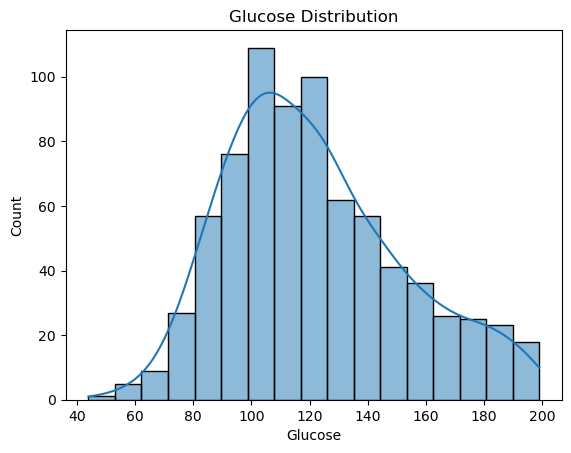

In [8]:
# Distribution example
sns.histplot(df['Glucose'], kde=True)
plt.title("Glucose Distribution")
plt.show()

## Classification Modelling

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import sklearn.linear_model as skl
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNetCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score

In [10]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
# Splitting Data for Training & Testing
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=1)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defining Fold for Cross Validation
kfold = KFold(5, random_state=123, shuffle=True)

## Logistic regression

### Baseline Logistics Regression

In [12]:
glm_fit = LogisticRegression(random_state=0).fit(X_train_scaled, y_train)

y_pred_glm = glm_fit.predict(X_test_scaled)
logit_pr = glm_fit.predict_proba(X_test_scaled)[:, 1]
logit_est = np.where(logit_pr > 0.5, 1, 0)

misclassification_error = np.mean(logit_est != y_test)
print(misclassification_error)

0.22727272727272727


In [13]:
print("Accuracy:", np.mean(logit_est == y_test))
print('roc_auc', roc_auc_score(y_test,logit_pr))
print("F-1 score:", f1_score(y_test, y_pred_glm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_glm))


Accuracy: 0.7727272727272727
roc_auc 0.8666666666666667
F-1 score: 0.6391752577319587
Confusion Matrix:
 [[88 11]
 [24 31]]


### Logistics Regression with Ridge

In [14]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'class_weight': [None, 'balanced']}

ridge_logit = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', random_state=0),
    param_grid,
    cv=kfold,
    scoring='roc_auc'
)

ridge_logit.fit(X_train_scaled, y_train)

print("Best parameter:", ridge_logit.best_params_)
print("Best CV score:", ridge_logit.best_score_)

y_pred_ridge = ridge_logit.best_estimator_.predict(X_test_scaled)
ridge_pr = ridge_logit.best_estimator_.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_ridge))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ridge))
print("Classification Report:\n", classification_report(y_test, y_pred_ridge))
print('roc-auc:', roc_auc_score(y_test, ridge_pr))
print("F-1 score:", f1_score(y_test, y_pred_ridge))

Best parameter: {'C': 1, 'class_weight': 'balanced'}
Best CV score: 0.834528722025522
Accuracy: 0.7922077922077922
Confusion Matrix:
 [[79 20]
 [12 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83        99
           1       0.68      0.78      0.73        55

    accuracy                           0.79       154
   macro avg       0.78      0.79      0.78       154
weighted avg       0.80      0.79      0.79       154

roc-auc: 0.8686868686868687
F-1 score: 0.7288135593220338


In [15]:
feature_names = X.columns
coef = ridge_logit.best_estimator_.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
}).sort_values('Abs_Coefficient', ascending=False)

print(importance_df.to_string(index=False))

                 Feature  Coefficient  Abs_Coefficient
                 Glucose     1.108883         1.108883
                     BMI     0.674293         0.674293
             Pregnancies     0.409189         0.409189
DiabetesPedigreeFunction     0.251196         0.251196
                     Age     0.196368         0.196368
           BloodPressure    -0.137290         0.137290
                 Insulin    -0.057058         0.057058
           SkinThickness     0.002215         0.002215


### Logistics Regression with Lasso

In [16]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'class_weight': [None, 'balanced']}

lasso_logit = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', random_state=0),
    param_grid,
    cv=kfold,
    scoring='roc_auc'
)

lasso_logit.fit(X_train_scaled, y_train)

print("Best parameter:", lasso_logit.best_params_)
print("Best CV score:", lasso_logit.best_score_)

y_pred_lasso = lasso_logit.best_estimator_.predict(X_test_scaled)
lasso_pr = lasso_logit.best_estimator_.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lasso))
print("Classification Report:\n", classification_report(y_test, y_pred_lasso))
print('roc_auc:', roc_auc_score(y_test,lasso_pr))
print("F-1 score:", f1_score(y_test, y_pred_lasso))

Best parameter: {'C': 1, 'class_weight': 'balanced'}
Best CV score: 0.8352301037214163
Accuracy: 0.7922077922077922
Confusion Matrix:
 [[79 20]
 [12 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83        99
           1       0.68      0.78      0.73        55

    accuracy                           0.79       154
   macro avg       0.78      0.79      0.78       154
weighted avg       0.80      0.79      0.79       154

roc_auc: 0.8679522497704316
F-1 score: 0.7288135593220338


In [17]:
feature_names = X.columns
coef = lasso_logit.best_estimator_.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
}).sort_values('Abs_Coefficient', ascending=False)

print(importance_df.to_string(index=False))

                 Feature  Coefficient  Abs_Coefficient
                 Glucose     1.103337         1.103337
                     BMI     0.664063         0.664063
             Pregnancies     0.404620         0.404620
DiabetesPedigreeFunction     0.242818         0.242818
                     Age     0.183617         0.183617
           BloodPressure    -0.121603         0.121603
                 Insulin    -0.043538         0.043538
           SkinThickness     0.000000         0.000000


### Bagging

In [18]:
# Bagging
param_grid = {
    'n_estimators': [10, 50, 100, 200, 300],
    'max_samples': [0.8, 1.0],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 3, 5], 
    'class_weight': [None, 'balanced']
}

bagging= RandomForestClassifier(max_features=X_train.shape[1], random_state=123)

bagging_grid = GridSearchCV(
    bagging,
    param_grid,
    cv=kfold,
    scoring="roc_auc",
    n_jobs=-1
)

bagging_grid.fit(X_train_scaled, y_train)

# predictions
y_train_pred_bag = bagging_grid.best_estimator_.predict(X_train_scaled)
y_test_pred_bag = bagging_grid.best_estimator_.predict(X_test_scaled)
bag_pr = bagging_grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]

# classification error = 1 - accuracy
train_accuracy_bag = accuracy_score(y_train, y_train_pred_bag)
test_accuracy_bag = accuracy_score(y_test, y_test_pred_bag)

print(bagging_grid.best_params_)
print("Bagging Training Error:", 1 - train_accuracy_bag)
print("Bagging Test Error:", 1 - test_accuracy_bag)
print("Accuracy", test_accuracy_bag)
print('roc_auc:', roc_auc_score(y_test,bag_pr))
print("F-1 score:", f1_score(y_test, y_test_pred_bag))

{'class_weight': 'balanced', 'max_depth': 5, 'max_samples': 1.0, 'min_samples_leaf': 5, 'n_estimators': 50}
Bagging Training Error: 0.16775244299674263
Bagging Test Error: 0.18181818181818177
Accuracy 0.8181818181818182
roc_auc: 0.8740128558310376
F-1 score: 0.7666666666666667


### Random Forest

In [19]:
param_grid = {
    "n_estimators": [10, 50, 100, 200, 300],
    'max_samples': [0.8, 1.0],
    "max_features": [1, "sqrt", int(X_train.shape[1] / 2)],
    "min_samples_leaf": [1, 3, 5],
    'max_depth': [3, 5, None], 
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=123)

rf_grid = GridSearchCV(
    rf,
    param_grid,
    cv=kfold,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

Best RF params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_samples_leaf': 3, 'n_estimators': 50}


In [20]:
y_train_pred_rf = best_rf.predict(X_train_scaled)
y_test_pred_rf = best_rf.predict(X_test_scaled)
rf_pr = best_rf.predict_proba(X_test_scaled)[:, 1]

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("RF Training Error:", 1 - train_accuracy_rf)
print("RF Test Error:", 1 - test_accuracy_rf)
print("Accuracy:", test_accuracy_rf)
print('roc_auc:', roc_auc_score(y_test,rf_pr))
print("F-1 score:", f1_score(y_test, y_test_pred_rf))

RF Training Error: 0.09283387622149841
RF Test Error: 0.16233766233766234
Accuracy: 0.8376623376623377
roc_auc: 0.8795224977043159
F-1 score: 0.782608695652174


Feature Importance

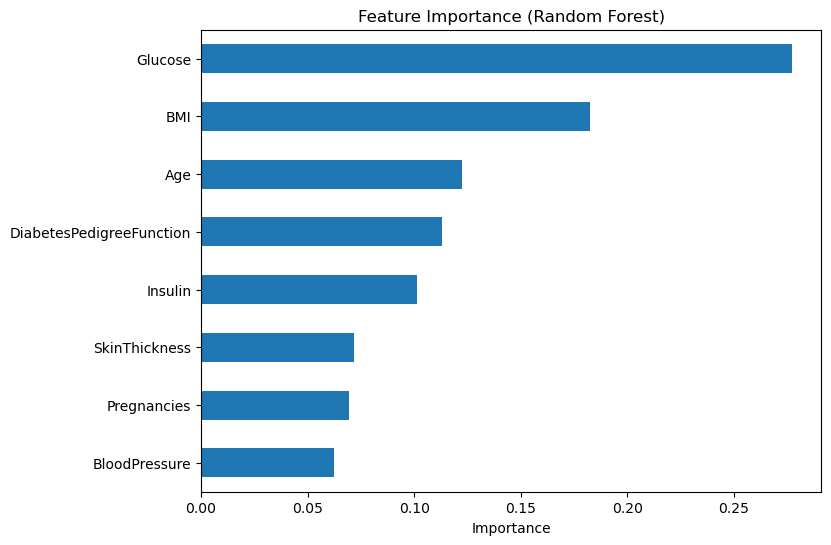

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
importances.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

The tuned bagging model achieved a training error of 0.168 and a test error of 0.182, corresponding to a test accuracy of approximately 0.818. The model also produced a ROC-AUC of 0.874 and an F1-score of 0.767.

After hyperparameter tuning, the random forest model achieved a training error of 0.093 and a test error of 0.162, with a test accuracy of approximately 0.838. It also achieved a ROC-AUC of 0.880 and an F1-score of 0.783, outperforming the bagging model across all evaluation metrics.

The lower test error and higher AUC indicate that random forest provides a better balance between bias and variance. By introducing randomness in feature selection (max_features = sqrt), the model improves generalization compared to bagging.

The feature importance plot shows that:

Glucose is by far the most important predictor
BMI is the second most important feature
Other features such as Age and Diabetes Pedigree Function contribute moderately
Variables like Blood Pressure and Skin Thickness have relatively low importance

This pattern is consistent with domain knowledge, as glucose level and BMI are well-known key indicators of diabetes risk.

### K-Nearest Neighbor Approach

In [22]:
n_neighbors_grid = {
    'n_neighbors': range(1, 56, 2)
}

knn = KNeighborsClassifier(weights = 'uniform')
knn_grid = GridSearchCV(knn, n_neighbors_grid, refit = True, cv = kfold, scoring = 'roc_auc')
knn_model = knn_grid.fit(X_train_scaled, y_train)

test_pred_knn = knn_model.best_estimator_.predict(X_test_scaled)
knn_pr = knn_model.best_estimator_.predict_proba(X_test_scaled)[:, 1]

# Compute metrics
accuracy = accuracy_score(y_test, test_pred_knn)
test_error = 1 - accuracy

best_k = knn_model.best_params_['n_neighbors']
print("Best K:", best_k)
print("Accuracy:", accuracy)
print(f"The test classification error of the KNN model (N={best_k}) is", test_error)
print('roc_auc:', roc_auc_score(y_test,knn_pr))
print("F-1 score:", f1_score(y_test, test_pred_knn))

Best K: 55
Accuracy: 0.7987012987012987
The test classification error of the KNN model (N=55) is 0.2012987012987013
roc_auc: 0.8804407713498622
F-1 score: 0.6593406593406593


### Neural Network Approach

In [23]:
param_grid = {
    'hidden_layer_sizes': [(3,), (5,), (10,), (25,),
                            (3,3), (5,5), (10,10), (25,25)],
    'activation': ['relu'],
    'alpha': [0.0001, 0.001, 0.01], 
    'learning_rate_init': [0.001, 0.01]
}

nn = MLPClassifier(max_iter = 4000, random_state = 123)
nn_grid = GridSearchCV(nn, param_grid, cv = kfold, scoring = 'roc_auc', n_jobs = -1)
nn_model = nn_grid.fit(X_train_scaled, y_train)

# Get best parameters
best_params = nn_model.best_params_
print("Best params:", best_params)

# Compute metrics
test_pred_nn = nn_model.best_estimator_.predict(X_test_scaled)
nn_pr = nn_model.best_estimator_.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, test_pred_nn)
test_error = 1 - accuracy

print("Test accuracy:", accuracy)
print("The test classification error of the neural network model is", test_error)
print('roc_auc:', roc_auc_score(y_test,nn_pr))
print("F-1 score:", f1_score(y_test, test_pred_nn))

Best params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (5,), 'learning_rate_init': 0.001}
Test accuracy: 0.8116883116883117
The test classification error of the neural network model is 0.18831168831168832
roc_auc: 0.8866850321395776
F-1 score: 0.7238095238095238


Neural network appears to be the best performing model. However, the best performing neural network is a simple single hidden layer with 5 neurons. This suggested that the relationship in this data is mostly linear.